<a href="https://colab.research.google.com/github/Avi0095/Deep-Learning/blob/main/Self_organising_map(SOM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
dataset=pd.read_csv('/content/Credit_Card_Applications.csv')
X=dataset.iloc[:, :-1].values
y=dataset.iloc[:,-1].values

Feature Scaling

In [7]:
from sklearn.preprocessing import MinMaxScaler
sc=MinMaxScaler(feature_range=(0,1))
X=sc.fit_transform(X)


training the SOM

In [10]:
!pip install minisom

In [19]:
from minisom import MiniSom
som=MiniSom(x=10,y=10,input_len=15,sigma=1.0,learning_rate=0.5)
som.random_weights_init(X)
som.train_random(data=X,num_iteration=100)


visualise the results

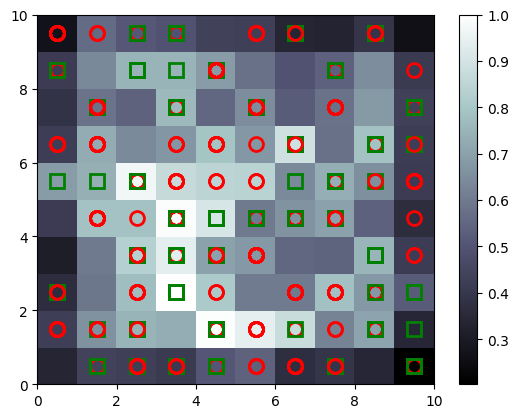

In [21]:
from pylab import bone,pcolor,colorbar,plot,show
bone()
pcolor(som.distance_map().T)
colorbar()
markers=['o','s']
colors=['r','g']
for i,x in enumerate(X):
  w=som.winner(x)
  plot(w[0]+0.5,
       w[1]+0.5,
       markers[y[i]],
       markeredgecolor=colors[y[i]],
       markerfacecolor='None',
       markersize=10,
       markeredgewidth=2)
show()

finding the frauds

In [23]:
mappings=som.win_map(X)
frauds=np.concatenate((mappings[(4,1)],mappings[(3,2)],mappings[(3,4)],mappings[(2,5)]),axis=0)
frauds=sc.inverse_transform(frauds)
frauds

array([[1.5805212e+07, 1.0000000e+00, 1.9670000e+01, 1.0000000e+01,
        1.0000000e+00, 4.0000000e+00, 8.0000000e+00, 8.3500000e-01,
        1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.0000000e+00,
        2.0000000e+00, 1.4000000e+02, 1.0000000e+00],
       [1.5785339e+07, 1.0000000e+00, 3.5250000e+01, 3.1650000e+00,
        2.0000000e+00, 1.4000000e+01, 8.0000000e+00, 3.7500000e+00,
        1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.0000000e+00,
        2.0000000e+00, 6.8000000e+02, 1.0000000e+00],
       [1.5803682e+07, 1.0000000e+00, 4.8580000e+01, 6.5000000e+00,
        2.0000000e+00, 1.1000000e+01, 8.0000000e+00, 6.0000000e+00,
        1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.0000000e+00,
        2.0000000e+00, 3.5000000e+02, 1.0000000e+00],
       [1.5770406e+07, 1.0000000e+00, 3.2670000e+01, 9.0000000e+00,
        1.0000000e+00, 9.0000000e+00, 8.0000000e+00, 5.2500000e+00,
        1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.0000000e+00,
        2.0000000e+00,

In [24]:
fraud_customers = []

for i in range(len(X)):
    for j in range(len(frauds)):
        if np.all(X[i] == sc.transform(frauds[j].reshape(1, -1))):
            fraud_customers.append(dataset.iloc[i, 0])  # 0 = CustomerID column


In [27]:
for customer in fraud_customers:
    print(customer)

15786237
15585855
15805212
15785339
15567839
15671014
15624595
15579583
15642336
15591360
15740487
15720644
15811742
15589881
15592326
15671293
15702571
15622083
15803682
15715907
15770406
15773776
15768342
15781975
15700511
15580579
15748532
15568819
15762392
15689692
15699294
15788634
